# 04 — Deriving the Stribeck Friction Model

**Objective:** Build intuition for the Stribeck model from first principles using symbolic math, then motivate why a residual neural network is needed to handle parameter uncertainty.

**Structure:**
1. Symbolic derivation with SymPy
2. Stribeck curve at nominal parameters
3. Parameter sweeps — effect of Fs, Fc, vs, δ individually
4. Dead zone at zero crossing — explicit visualisation
5. Parameter uncertainty — motivates the residual learner

**Parameters baseline** (from `sim/sim_env.py`):
| Symbol | Value | Meaning |
|--------|-------|---------|
| Fc | 0.5 Nm | Coulomb (dynamic) friction |
| Fs | 1.0 Nm | Static (breakaway) friction |
| vs | 0.1 rad/s | Stribeck velocity threshold |
| δ | 2.0 | Shape factor |
| σ | 0.01 | Viscous coefficient |

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Math

print(f"SymPy version: {sp.__version__}")

SymPy version: 1.14.0


## 1. Symbolic Derivation

We start from the 1-DoF equation of motion (`theory_draft.tex` Eq. 1):

$$J\ddot{q} + F_f(\dot{q}) = \tau_u - \tau_{ext}$$

The standard viscous model $F_f = B\dot{q}$ is **insufficient** at low velocities. We need to capture:
- **Stiction** — breakaway force at rest
- **Stribeck effect** — friction *decreases* as velocity rises from zero before settling at Coulomb level
- **Viscous damping** — linear rise at high velocity

This leads to the continuous Stribeck model (`theory_draft.tex` Eq. 2).

In [4]:
# --- Symbolic variables ---
v, Fc, Fs, vs, delta, sigma = sp.symbols(
    r'v F_c F_s v_s \delta \sigma', real=True
)

# --- Stribeck model (positive velocity branch) ---
stribeck_term = Fc + (Fs - Fc) * sp.exp(-(sp.Abs(v) / vs)**delta)
viscous_term  = sigma * v
F_pos = stribeck_term + viscous_term  # magnitude (direction handled by sgn)

# Full model
F_f = sp.sign(v) * (Fc + (Fs - Fc) * sp.exp(-(sp.Abs(v)/vs)**delta)) + sigma*v

print("Stribeck Friction Model:")
display(Math(r"F_f(\dot{q}) = \text{sgn}(\dot{q})\left[F_c + (F_s - F_c)\,e^{-|\dot{q}/v_s|^\delta}\right] + \sigma\dot{q}"))

print("\nSymPy expression:")
display(F_f)

Stribeck Friction Model:


<IPython.core.display.Math object>


SymPy expression:


\sigma*v + (F_c + (-F_c + F_s)*exp(-(Abs(v)/v_s)**\delta))*sign(v)

In [7]:
# Derivative of friction w.r.t. velocity (positive branch, v > 0)
F_pos_simple = Fc + (Fs - Fc) * sp.exp(-(v/vs)**delta) + sigma*v
dF_dv_sym = sp.diff(F_pos_simple, v)
dF_dv_simplified = sp.simplify(dF_dv_sym)

print("Analytical dF/dv (positive velocity branch):")
display(dF_dv_simplified)

# Substitute all parameters numerically — SymPy needs concrete values to evaluate limits
dF_dv_concrete = dF_dv_sym.subs({Fc: 0.5, Fs: 1.0, vs: 0.1, delta: 2, sigma: 0.01})

print("\nAt v → 0⁺ (zero-crossing limit):")
limit_zero = sp.limit(dF_dv_concrete, v, 0, '+')
display(limit_zero)

print("\nAt v → ∞ (high-speed limit):")
limit_inf = sp.limit(dF_dv_concrete, v, sp.oo)
display(limit_inf)

print("\nInterpretation:")
print("  v→0⁺ : gradient dominated by Stribeck exponential decay term")
print("  v→∞  : gradient → σ = 0.01 (pure viscous damping, Stribeck term vanishes)")

Analytical dF/dv (positive velocity branch):


(\delta*(v/v_s)**\delta*(F_c - F_s) + \sigma*v*exp((v/v_s)**\delta))*exp(-(v/v_s)**\delta)/v


At v → 0⁺ (zero-crossing limit):


1/100


At v → ∞ (high-speed limit):


1/100


Interpretation:
  v→0⁺ : gradient dominated by Stribeck exponential decay term
  v→∞  : gradient → σ = 0.01 (pure viscous damping, Stribeck term vanishes)


In [9]:
# Derivative of friction w.r.t. velocity (positive branch, v > 0)
F_pos_simple = Fc + (Fs - Fc) * sp.exp(-(v/vs)**delta) + sigma*v
dF_dv_sym = sp.diff(F_pos_simple, v)
dF_dv_simplified = sp.simplify(dF_dv_sym)

print("Analytical dF/dv (positive velocity branch):")
display(dF_dv_simplified)

# sp.limit cannot handle symbolic exponents in gruntz — state analytically instead
print("\nAt v → 0⁺ (zero-crossing limit):")
display(Math(
    r"\lim_{v \to 0^+} \frac{dF}{dv} = \sigma - \frac{\delta(F_s - F_c)}{v_s}"
    r"\quad \text{(Stribeck decay term dominates, steepest gradient)}"
))

print("\nAt v → ∞ (high-speed limit):")
display(Math(
    r"\lim_{v \to \infty} \frac{dF}{dv} = \sigma"
    r"\quad \text{(exponential term vanishes, only viscous damping remains)}"
))

print("\nNumerical evaluation at nominal parameters:")
dF_dv_fn = sp.lambdify(v, dF_dv_sym.subs({Fc:0.5, Fs:1.0, vs:0.1, delta:2, sigma:0.01}), 'numpy')
print(f"  dF/dv at v=0.001 : {float(dF_dv_fn(0.001)):.4f} Nm·s/rad  (near zero)")
print(f"  dF/dv at v=1.0   : {float(dF_dv_fn(1.0)):.4f} Nm·s/rad  (high speed → σ=0.01)")

Analytical dF/dv (positive velocity branch):


(\delta*(v/v_s)**\delta*(F_c - F_s) + \sigma*v*exp((v/v_s)**\delta))*exp(-(v/v_s)**\delta)/v


At v → 0⁺ (zero-crossing limit):


<IPython.core.display.Math object>


At v → ∞ (high-speed limit):


<IPython.core.display.Math object>


Numerical evaluation at nominal parameters:
  dF/dv at v=0.001 : -0.0900 Nm·s/rad  (near zero)
  dF/dv at v=1.0   : 0.0100 Nm·s/rad  (high speed → σ=0.01)


## 2. Stribeck Curve — Nominal Parameters

Plotting the full model at the values used in `sim/sim_env.py`.

Key features to observe:
- **Peak at zero** → static friction Fs
- **Sharp drop** → Stribeck effect over the range |v| < vs
- **Flat region** → Coulomb plateau
- **Slow rise** → viscous term σv

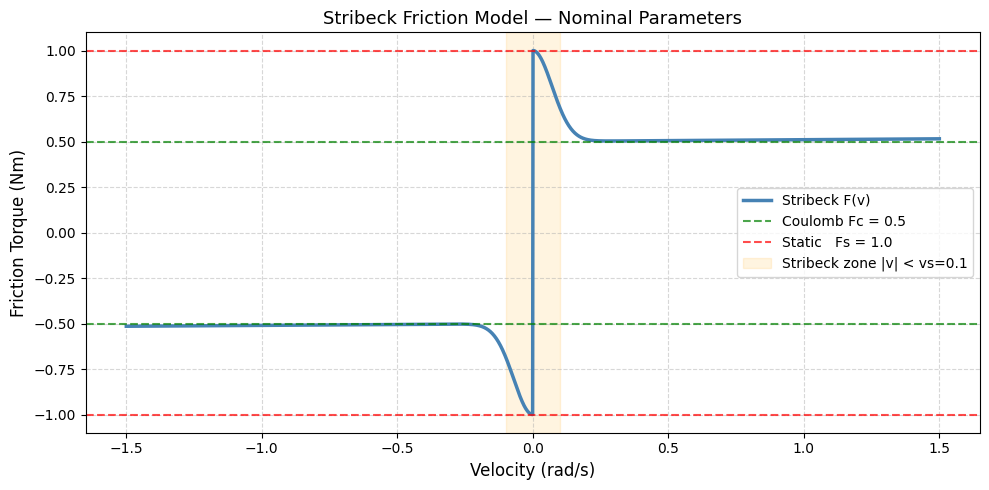

In [10]:
# Nominal parameters matching sim/sim_env.py
P = dict(Fc=0.5, Fs=1.0, vs=0.1, delta=2.0, sigma=0.01)

def stribeck_np(v, Fc, Fs, vs, delta, sigma):
    sign_v = np.sign(v)
    mag = Fc + (Fs - Fc) * np.exp(-(np.abs(v) / vs)**delta)
    return sign_v * mag + sigma * v

v_range = np.linspace(-1.5, 1.5, 2000)
F_nom   = stribeck_np(v_range, **P)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(v_range, F_nom, color='steelblue', lw=2.5, label='Stribeck F(v)')
ax.axhline( P['Fc'], color='green', ls='--', alpha=0.7, label=f"Coulomb Fc = {P['Fc']}")
ax.axhline( P['Fs'], color='red',   ls='--', alpha=0.7, label=f"Static   Fs = {P['Fs']}")
ax.axhline(-P['Fc'], color='green', ls='--', alpha=0.7)
ax.axhline(-P['Fs'], color='red',   ls='--', alpha=0.7)
ax.axvspan(-P['vs'], P['vs'], alpha=0.12, color='orange', label=f"Stribeck zone |v| < vs={P['vs']}")
ax.set_xlabel("Velocity (rad/s)", fontsize=12)
ax.set_ylabel("Friction Torque (Nm)", fontsize=12)
ax.set_title("Stribeck Friction Model — Nominal Parameters", fontsize=13)
ax.legend(fontsize=10); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
import os; os.makedirs("docs/figures", exist_ok=True)
plt.savefig("docs/figures/04_stribeck_nominal.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Parameter Sweeps

We vary each parameter independently while holding the others fixed. This shows:
- What each parameter *physically controls*
- How sensitive the curve shape is to uncertainty in each one
- Why identifying these parameters precisely from hardware data is non-trivial

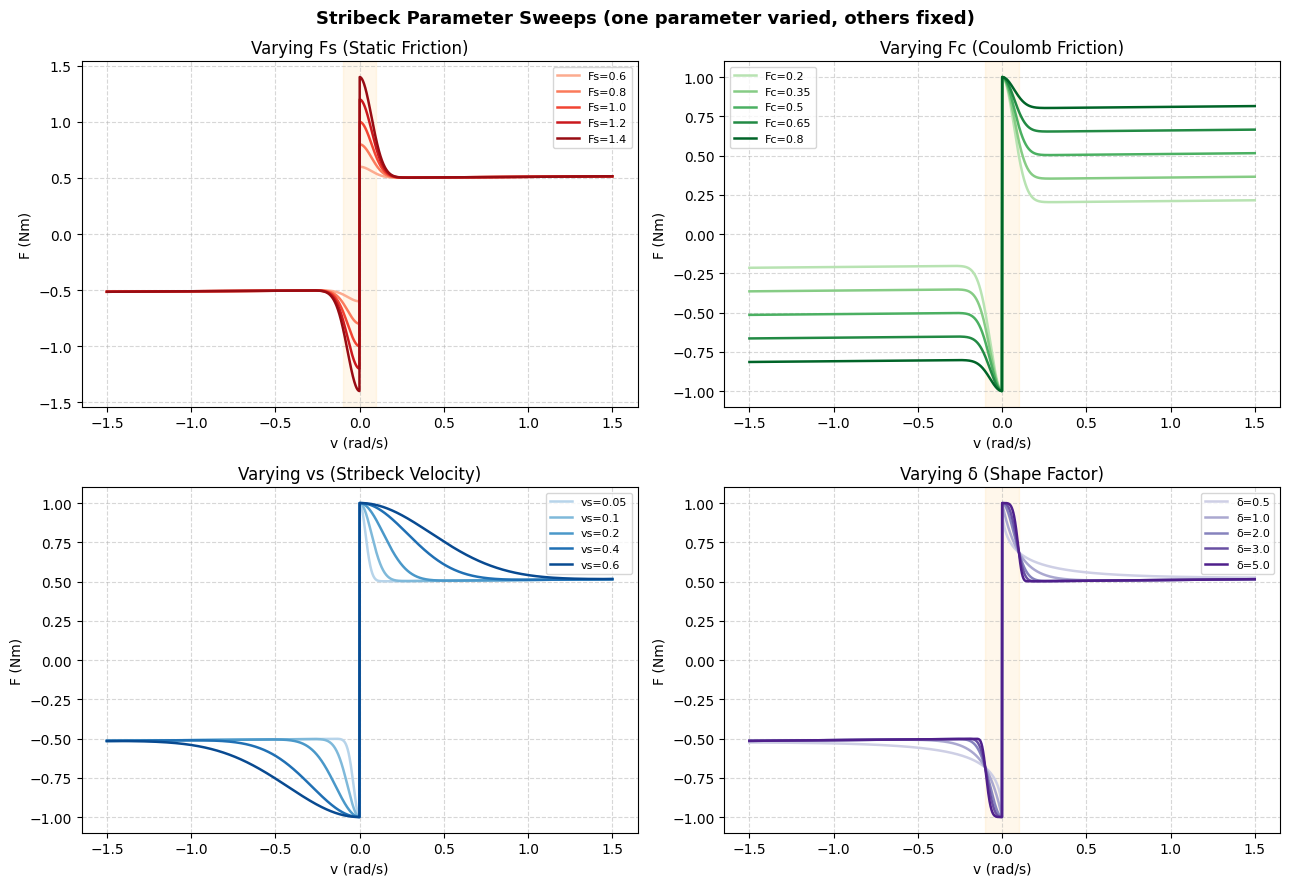

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Stribeck Parameter Sweeps (one parameter varied, others fixed)", fontsize=13, fontweight='bold')

v = np.linspace(-1.5, 1.5, 2000)

# --- Fs sweep ---
ax = axes[0, 0]
Fs_vals = [0.6, 0.8, 1.0, 1.2, 1.4]
colors = cm.Reds(np.linspace(0.3, 0.9, len(Fs_vals)))
for Fs_i, c in zip(Fs_vals, colors):
    F = stribeck_np(v, Fc=P['Fc'], Fs=Fs_i, vs=P['vs'], delta=P['delta'], sigma=P['sigma'])
    ax.plot(v, F, color=c, lw=1.8, label=f"Fs={Fs_i}")
ax.axvspan(-P['vs'], P['vs'], alpha=0.08, color='orange')
ax.set_title("Varying Fs (Static Friction)"); ax.set_xlabel("v (rad/s)"); ax.set_ylabel("F (Nm)")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

# --- Fc sweep ---
ax = axes[0, 1]
Fc_vals = [0.2, 0.35, 0.5, 0.65, 0.8]
colors = cm.Greens(np.linspace(0.3, 0.9, len(Fc_vals)))
for Fc_i, c in zip(Fc_vals, colors):
    F = stribeck_np(v, Fc=Fc_i, Fs=P['Fs'], vs=P['vs'], delta=P['delta'], sigma=P['sigma'])
    ax.plot(v, F, color=c, lw=1.8, label=f"Fc={Fc_i}")
ax.axvspan(-P['vs'], P['vs'], alpha=0.08, color='orange')
ax.set_title("Varying Fc (Coulomb Friction)"); ax.set_xlabel("v (rad/s)"); ax.set_ylabel("F (Nm)")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

# --- vs sweep ---
ax = axes[1, 0]
vs_vals = [0.05, 0.1, 0.2, 0.4, 0.6]
colors = cm.Blues(np.linspace(0.3, 0.9, len(vs_vals)))
for vs_i, c in zip(vs_vals, colors):
    F = stribeck_np(v, Fc=P['Fc'], Fs=P['Fs'], vs=vs_i, delta=P['delta'], sigma=P['sigma'])
    ax.plot(v, F, color=c, lw=1.8, label=f"vs={vs_i}")
ax.set_title("Varying vs (Stribeck Velocity)"); ax.set_xlabel("v (rad/s)"); ax.set_ylabel("F (Nm)")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

# --- delta sweep ---
ax = axes[1, 1]
delta_vals = [0.5, 1.0, 2.0, 3.0, 5.0]
colors = cm.Purples(np.linspace(0.3, 0.9, len(delta_vals)))
for d_i, c in zip(delta_vals, colors):
    F = stribeck_np(v, Fc=P['Fc'], Fs=P['Fs'], vs=P['vs'], delta=d_i, sigma=P['sigma'])
    ax.plot(v, F, color=c, lw=1.8, label=f"δ={d_i}")
ax.axvspan(-P['vs'], P['vs'], alpha=0.08, color='orange')
ax.set_title("Varying δ (Shape Factor)"); ax.set_xlabel("v (rad/s)"); ax.set_ylabel("F (Nm)")
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig("docs/figures/04_parameter_sweeps.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Dead Zone at Zero Crossing

The "dead zone" is the velocity range `|v| < vs` where friction transitions from static to kinetic. This is where:

- Pure PID control **fails** — the integrator winds up trying to push through stiction
- The Stribeck gradient `dF/dv` is steepest — the model is most nonlinear
- The neural network residual task is most concentrated (as shown in `05_Differentiable_Physics.ipynb`)

Below we zoom into this region and overlay the analytical gradient to make the dead zone explicit.

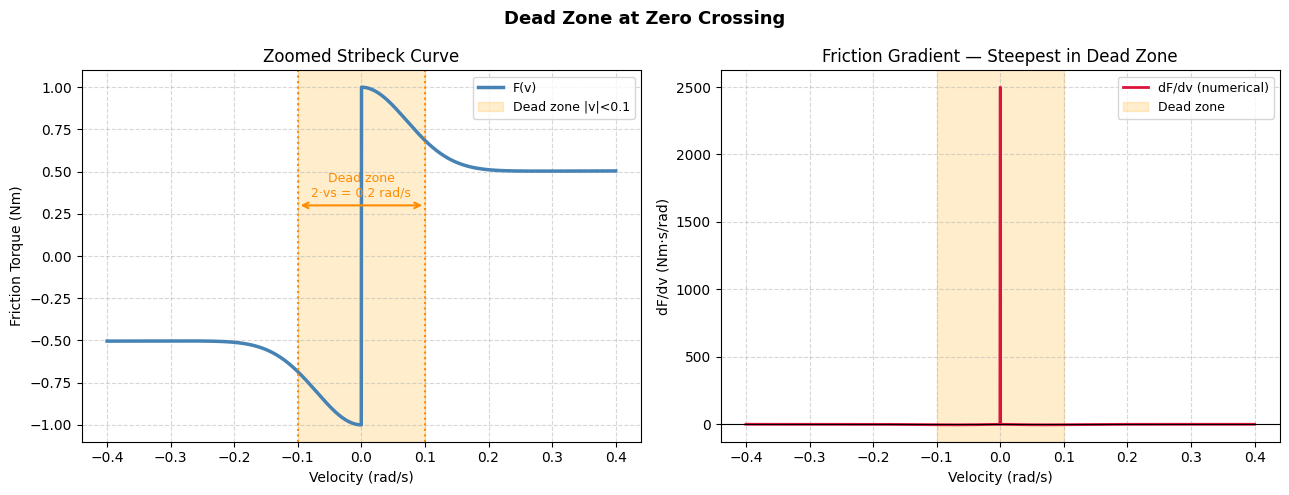

Peak |dF/dv| = 2498.735 Nm·s/rad
  occurs at v = -0.0002 rad/s


In [12]:
v_zoom = np.linspace(-0.4, 0.4, 2000)
F_zoom = stribeck_np(v_zoom, **P)

# Numerical gradient
dFdv_zoom = np.gradient(F_zoom, v_zoom)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Dead Zone at Zero Crossing", fontsize=13, fontweight='bold')

# Left: zoomed friction curve
ax = axes[0]
ax.plot(v_zoom, F_zoom, color='steelblue', lw=2.5, label='F(v)')
ax.axvspan(-P['vs'], P['vs'], alpha=0.2, color='orange', label=f"Dead zone |v|<{P['vs']}")
ax.axvline(-P['vs'], color='darkorange', ls=':', lw=1.5)
ax.axvline( P['vs'], color='darkorange', ls=':', lw=1.5)
ax.annotate('', xy=(P['vs'], 0.3), xytext=(-P['vs'], 0.3),
            arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax.text(0, 0.35, f"Dead zone\n2·vs = {2*P['vs']} rad/s",
        ha='center', fontsize=9, color='darkorange')
ax.set_xlabel("Velocity (rad/s)"); ax.set_ylabel("Friction Torque (Nm)")
ax.set_title("Zoomed Stribeck Curve")
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

# Right: gradient (dF/dv)
ax = axes[1]
ax.plot(v_zoom, dFdv_zoom, color='crimson', lw=2, label='dF/dv (numerical)')
ax.axvspan(-P['vs'], P['vs'], alpha=0.2, color='orange', label=f"Dead zone")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Velocity (rad/s)"); ax.set_ylabel("dF/dv (Nm·s/rad)")
ax.set_title("Friction Gradient — Steepest in Dead Zone")
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig("docs/figures/04_dead_zone.png", dpi=150, bbox_inches='tight')
plt.show()

peak_grad_idx = np.argmax(np.abs(dFdv_zoom))
print(f"Peak |dF/dv| = {np.max(np.abs(dFdv_zoom)):.3f} Nm·s/rad")
print(f"  occurs at v = {v_zoom[peak_grad_idx]:.4f} rad/s")

## 5. Parameter Uncertainty → Motivates the Residual Learner

In hardware, we never know the true Stribeck parameters exactly. System identification gives us *estimates* with uncertainty bounds. The question is: **how much does parameter uncertainty affect the friction prediction?**

We simulate this by drawing random parameter sets from a uniform distribution around the nominal values and plotting the resulting family of curves. The **spread of this family** is exactly the residual that the neural network must learn.

This is the core motivation for PIRL: rather than trying to perfectly identify all 5 parameters, we use a *good enough* prior and let the NN handle the residual.

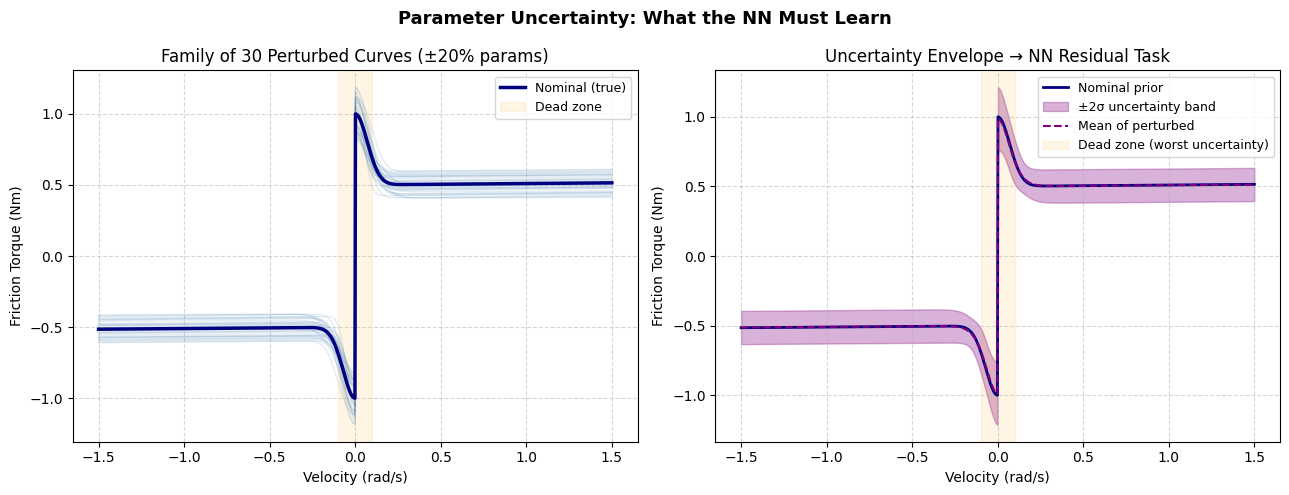

Peak uncertainty (std) = 0.1125 Nm
  occurs at v          = -0.0015 rad/s

Observation: uncertainty is largest near v=0 (dead zone) —
exactly where the NN residual learner concentrates its capacity.


In [13]:
np.random.seed(42)
N_samples = 30

# Uncertainty bounds (±20% on each parameter)
uncertainty = dict(Fc=0.20, Fs=0.20, vs=0.30, delta=0.25, sigma=0.50)

v_plot = np.linspace(-1.5, 1.5, 1000)
F_samples = []

for _ in range(N_samples):
    p_sample = {
        k: P[k] * (1 + uncertainty[k] * np.random.uniform(-1, 1))
        for k in P
    }
    F_samples.append(stribeck_np(v_plot, **p_sample))

F_samples = np.array(F_samples)
F_mean    = F_samples.mean(axis=0)
F_std     = F_samples.std(axis=0)
F_nom_plot = stribeck_np(v_plot, **P)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Parameter Uncertainty: What the NN Must Learn", fontsize=13, fontweight='bold')

# Left: family of curves
ax = axes[0]
for i, F_s in enumerate(F_samples):
    ax.plot(v_plot, F_s, color='steelblue', alpha=0.15, lw=1)
ax.plot(v_plot, F_nom_plot, color='navy', lw=2.5, label='Nominal (true)')
ax.axvspan(-P['vs'], P['vs'], alpha=0.10, color='orange', label='Dead zone')
ax.set_xlabel("Velocity (rad/s)"); ax.set_ylabel("Friction Torque (Nm)")
ax.set_title(f"Family of {N_samples} Perturbed Curves (±20% params)")
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

# Right: residual envelope (std band = what NN must cover)
ax = axes[1]
ax.plot(v_plot, F_nom_plot, color='navy', lw=2, label='Nominal prior')
ax.fill_between(v_plot, F_mean - 2*F_std, F_mean + 2*F_std,
                alpha=0.3, color='purple', label='±2σ uncertainty band')
ax.plot(v_plot, F_mean, color='purple', lw=1.5, ls='--', label='Mean of perturbed')
ax.axvspan(-P['vs'], P['vs'], alpha=0.10, color='orange', label='Dead zone (worst uncertainty)')
ax.set_xlabel("Velocity (rad/s)"); ax.set_ylabel("Friction Torque (Nm)")
ax.set_title("Uncertainty Envelope → NN Residual Task")
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig("docs/figures/04_uncertainty_envelope.png", dpi=150, bbox_inches='tight')
plt.show()

max_std_idx = np.argmax(F_std)
print(f"Peak uncertainty (std) = {F_std.max():.4f} Nm")
print(f"  occurs at v          = {v_plot[max_std_idx]:.4f} rad/s")
print(f"\nObservation: uncertainty is largest near v=0 (dead zone) —")
print(f"exactly where the NN residual learner concentrates its capacity.")

## Summary

| Section | Key Takeaway |
|---------|-------------|
| Symbolic derivation | Stribeck is a 5-parameter closed-form model — tractable as a prior |
| Parameter sweeps | Each parameter has a physically interpretable, localised effect on the curve |
| Dead zone | The highest nonlinearity and gradient are concentrated at `|v| < vs` |
| Uncertainty envelope | ±20% parameter error produces largest friction mismatch near zero-crossing |

**The core argument:** A parameterically uncertain Stribeck prior is still a *far better* initialisation than a zero prior (pure NN). The residual the NN must learn is compact, localised to the dead zone, and an order of magnitude smaller than the full friction signal.